In [291]:
import sys
sys.path.append(r"C:\nirfasterFF")
import nirfasterff as ff # ff is short for fast and furious
import numpy as np
import matplotlib.pyplot as plt

In [292]:
mua = 0.01
mus = 0.33 # approx same as musp here
ri = 1.33
mua_pert_percent = 0.01
mus_pert_percent = 0.01

Meshing parameters

In [293]:
vol = 2 * np.ones((60,60,60))
vol = vol.astype(np.uint8)

meshing_params = ff.utils.MeshingParams(
    xPixelSpacing=0.5,  
    yPixelSpacing=0.5,
    SliceThickness=0.5,
    general_cell_size=1.0,  
    cell_radius_edge=1.5,  
    facet_size=1.5, 
    facet_distance=1.0
)
# call the mesher
ele, nodes = ff.meshing.RunCGALMeshGenerator(vol, opt = meshing_params)

In [294]:
mesh = ff.base.stndmesh()
mesh.from_solid(ele, nodes)

# for each row, [region, mua(mm-1), musp(mm-1), ri]
prop = np.array([[1, mua, mus, ri]])
mesh.set_prop(prop)
mesh.kappa = 1 / (3*(mesh.mua + mesh.mus))
# set link (source-detector pairs)
mesh.link = np.array([[1,1,1]],dtype=np.int32)
# optodes
mesh.source = ff.base.optode(np.array([5,30,60]))
mesh.meas = ff.base.optode(np.array([55,30,60]))
# move them (for non-fixed) and calculate the integration function
mesh.touch_optodes()

touching sources
touching detectors


Create grid space

In [295]:
cube_grid_dim = 60

xgrid = np.arange(0., cube_grid_dim, 0.5)
ygrid = np.arange(0., cube_grid_dim, 0.5)
zgrid = np.arange(0., cube_grid_dim, 0.5)

mesh.gen_intmat(xgrid, ygrid, zgrid)

Define Ultrasound(US) parameters

In [296]:
wv = 785 #nm
k0 = 2*np.pi / (wv/1e6)

#US parameters
fa = 5e6  # frequency of US (Hz)
va = 1480*1e3   # acoustic wave velocity
ka = 2*np.pi / (va/(fa))  # va=1480m/s
wa = 2*np.pi*fa   # 2*pi*fa
ltr = 1/mesh.mus
rho = 1000*1e-9   # for water
eta = 0.32       # for water
Sa = 1.
phi = 0.
P0 = 1e5  # US pressue(pascal)
tau = 0.5*(1/fa)  #T/2

Define US size, shape, position, and select nodes that falls inside the US-field

In [ ]:
# Define UltraSound position
x_cen_us,y_cen_us,z_cen_us = [30,30,30] #centre of the US , z-pos is measured from bottom surface(starting from 0) to top surface here in the mesh space
                               #(although in general terminology, its expressed as depth from top surface)

# For cylinder-shaped US-focus
dist = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_us)) + np.square((mesh.nodes[:,1]-y_cen_us)) + np.square((mesh.nodes[:,2]-z_cen_us)))
height = 8  #height of cylinder
dia = 3     #diameter of cylinder
ind= np.zeros(len(mesh.nodes))

for i in range(len(mesh.nodes)):     # selecting nodes for Cylindrical US: Z-axis aligned   
    if mesh.nodes[i,2]>(z_cen_us-height/2) and mesh.nodes[i,2]<(z_cen_us+height/2) and np.sqrt((mesh.nodes[i,0]-x_cen_us)**2+(mesh.nodes[i,1]-y_cen_us)**2) < dia/2 :
        ind[i] = dist[i] 



# For sperically-shaped US-focus
# dia = 6
# dist = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_us)) + np.square((mesh.nodes[:,1]-y_cen_us)) + np.square((mesh.nodes[:,2]-z_cen_us)))
# ind= np.zeros(len(mesh.nodes)) 
# ind = dist < dia/2


us_selection = np.argwhere(ind != 0)

Assign pressure values to selected US-nodes

In [298]:
p0 = np.zeros(len(mesh.mua))
p0[us_selection] = P0/1e3           #assigning a pressure value to the selected nodes within the cylindrical vol(also converting into N/mm2)

ht = (np.square((p0*k0*mesh.ri)/(ka*rho*va*va))) * (1-np.cos(wa*tau)) * ( (np.square(eta))*(ka*ltr)*(np.arctan(ka*ltr)) + Sa*Sa/3 - 2*eta*Sa/np.cos(phi))
#print(ht[ht!=0])

h(t) in grid space

In [299]:
#converting "ht" from mesh to grid space for later use, and creating the "(1+ht)" to multiply with mus-Jacobian

ht_mesh_2_grid = mesh.vol.mesh2grid@ht                         # mostly zeroes and only few points have a value corresponding to ht
ht_grid_selection = ht_mesh_2_grid  #>= ht[us_selection][0]    # IF.. you wanna set a threshold ;  holds "True" at indices where the condition is satisfied
ht_grid_indices = np.nonzero(ht_grid_selection)[0]      # selection of all indices whose the threshold is >0.8 , or is non-zero (points corresponding to nodes that has an ultrasound pressure value assigned)
                                                        # to select indices we can use either 'np.where()' or 'np.nonzero()'
#print(ht_grid_indices)

ht_grid = np.zeros_like(ht_mesh_2_grid)   # making a variable of the shape "ht_mesh_2_grid", ie (1728000,) ,  a flattened variable filled with zeros. This will be later multiplied with mua-Jacobian to create "J_US_mus_eff", only when US and the mus-inclusion aligns
one_plus_ht_grid = np.ones_like(ht_mesh_2_grid) # making a variable of the shape "ht_mesh_2_grid", ie (1728000,) ,  a flattened variable filled with ones. "(1+ht)" will be later multiplied with mus-Jacobian in general as a whole

one_plus_ht_grid[ht_grid_indices] = 1 + ht[us_selection][0]  # placing "(1+ht)" in selected positions to later multiply with mus-Jacobian
ht_grid[ht_grid_indices] = ht[us_selection][0]

ht_grid = ht_grid.reshape(1,-1)  # Reshaped to look similiar to a jacobian, shape: (1, 1728000)
one_plus_ht_grid = one_plus_ht_grid.reshape(1,-1)  # Reshaped to look similiar to a jacobian, shape: (1, 1728000)

#print(ht_grid[ht_grid!=1])

Create the US-Mesh

In [300]:
# making a duplicate of main mesh for creating the 'US-perturbed-mesh'
mesh_US = ff.base.stndmesh()
mesh_US.from_copy(mesh)

mesh_US.mua = mesh.mua + mesh.mus*ht   # mesh_US is now the US-perturbed mesh, 
                                      # mesh_US will be used in all subsequent cases below which involves US.
                                      
mesh_US.kappa = 1.0 / (3.0*(mesh_US.mua + mesh_US.mus))
#mesh_US.kappa = 1.0 / (3.0*(mesh_US.mus))

#### TEST 1: comparing [mua-Perturbation method-doD    vs     mua-jacobian method-doD] for US-perturbed mesh

In [301]:
#Scan parameters
start = 10
stop = 50
step = 10

posList = range(start,stop+1,step)
nPos = len(posList)

Scanning an absorber inclusion along z-axis with US-pos fixed and analysing the error of [Perturbation vs Jacobian method] for each inclusion position

In [302]:
J_US_mua = mesh_US.jacobian(normalize=False)[0]    # US-mua-Jacobian  # run the code block where mesh_US is initialized - (1, 1728000)

data_US = mesh_US.femdata(0)[0]                  # measured US boundary data at tau = T/2
data_US = data_US.amplitude

# creating duplicate of mesh_US for measuring US-perturbed-perturbation-model doD
mesh_US_pert = ff.base.stndmesh()

doD_mua_pert = np.zeros(nPos)
doD_mua_jacobian = np.zeros(nPos)
error_mua = np.zeros(nPos)

print('\n')

for i in range(0,nPos):
   mesh_US_pert.from_copy(mesh_US)       # mua of mesh_US_pert is same as mesh_US.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh_US
   




   # add a spherical absorption inclusion in mesh_US_pert
   dia_ab = 2   #diameter of spherical absorber
   x_cen_ab,y_cen_ab,z_cen_ab = [30,30,posList[i]]      #centre of the absorber
   dist_ab = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_ab)) + np.square((mesh.nodes[:,1]-y_cen_ab)) + np.square((mesh.nodes[:,2]-z_cen_ab)))
                                             #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes' 
   ind_ab = dist_ab < dia_ab/2
   mua_selection = np.where(ind_ab)           #of all node points, this is the selection of nodes where the absorber inclusion exists

   


   
   # Adding inclusion in the US-type mesh(in mesh-space) by modifying optical prop by some percentage, and calculate the forward data and sebsequently the perturbation doD
   if posList[i] != z_cen_us:
      mesh_US_pert.mua[mua_selection] = mesh_US_pert.mua[mua_selection] + mua_pert_percent*mesh_US_pert.mua[mua_selection] 
   if posList[i] == z_cen_us:                                 #only if the inclusion coincides with the US-position!
      mesh_US_pert.mua[mua_selection] = mesh_US_pert.mua[mua_selection] + mua_pert_percent*mesh_US_pert.mua[mua_selection] - mua_pert_percent*mesh_US_pert.mus[mua_selection]*ht[mua_selection]
   mesh_US_pert.kappa[mua_selection] = 1.0 / (3.0*(mesh_US_pert.mua[mua_selection] + mesh_US_pert.mus[mua_selection]))
   #mesh_US_pert.kappa[mua_selection] = 1.0 / (3.0*(mesh_US_pert.mus[mua_selection]))

   data_mesh_US_pert = mesh_US_pert.femdata(0)[0] 
   data_mesh_US_pert = data_mesh_US_pert.amplitude

   doD_mua_pert[i] = (((data_mesh_US_pert - data_US))).item()
  
   




   # Now calculate doD using the Jacobian method
   # creating the difference in absorption for selected nodes(to be multiplied with mua-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mua_selection] = mua_pert_percent*mesh_US.mua[mua_selection]         # this is the effective difference in abs (in mesh-space). a 1% change in 'just absorption' 
   dmua = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mua_jacobian[i] = (J_US_mua @ dmua).item()
   




   # Calculating the percentage error between both models
   error_mua[i] = (((doD_mua_jacobian[i]-doD_mua_pert[i])/doD_mua_pert[i])*100)



   #Compare
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mua_pert[i])
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mua_jacobian[i])
   print('percentage error:' , error_mua[i])
   print('\n')



Calculating direct field...
Calculating adjoint field...
Integrating...


doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: -6.0752616519855855e-15
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: -6.259207165344663e-15
percentage error: 3.0277792776045795


doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: -4.441868071038276e-14
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: -4.560364751698513e-14
percentage error: 2.6677217505142643


doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: -2.2060621444334376e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: -2.946106380852574e-13
percentage error: 33.54593787335013


doD from US-perturbed-absorption-blob-perturbation model at z = 20 mm: -1.6899240404041064e-12
doD from US-perturbed-absorption-blob-Jacobian: model at z = 20 mm: -1.6486120502903193e-12
percentage error: -2.4446063329514036


doD from US-perturbed-abso

##### Plot

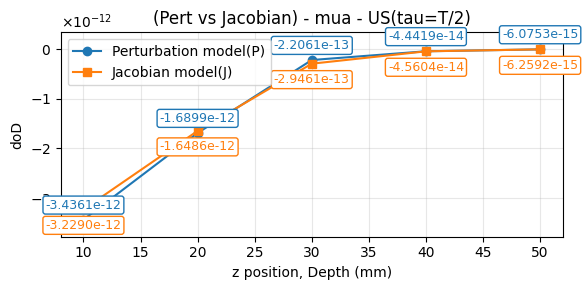

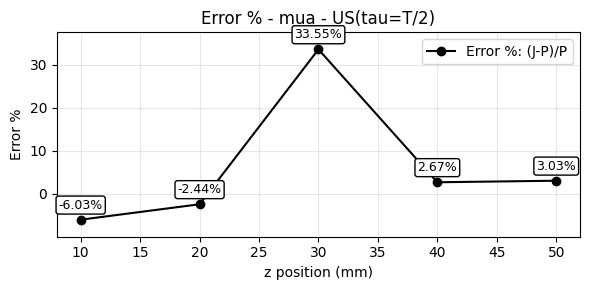

In [303]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Data
z_positions = []                   # creating an array that contains inclusion positions
for i in range(1, nPos+1):   
    z_positions.append(step * i)     
#print(z_positions)

x = z_positions
y_pert = doD_mua_pert[::-1]     # reversing to make it user friendly while displaying output(to display in ascending order of depth)
y_jac  = doD_mua_jacobian[::-1]
y_error = error_mua[::-1]    # reversing to make it user friendly while displaying output(to display in ascending order of depth)






# Comparison Plot
plt.figure(figsize=(6, 3))
line1, = plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model(P)')
line2, = plt.plot(x, y_jac,  marker='s', linewidth=1.5, label='Jacobian model(J)')
# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
# Zoom y-limits with padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Annotations: values at each point, colored by series and offset to avoid overlap
c1 = line1.get_color()
c2 = line2.get_color()
for xi, yi in zip(x, y_pert):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, 8), ha='center',
                color=c1, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c1, alpha=1))
for xi, yi in zip(x, y_jac):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, -14), ha='center',
                color=c2, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c2, alpha=1))
plt.xlabel('z position, Depth (mm)')
plt.ylabel('doD')
plt.title('(Pert vs Jacobian) - mua - US(tau=T/2)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()






# Error Plot
plt.figure(figsize=(6, 3))
line_err, = plt.plot(x, y_error, marker='o', linewidth=1.5, color='black', label='Error %: (J-P)/P')
# Zoom in around the min/max range with 10% padding
y_min = np.min(y_error)
y_max = np.max(y_error)
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Get the line color
c_err = line_err.get_color()
# Annotate each point
for xi, yi in zip(x, y_error):
    plt.annotate(f'{yi:.2f}%', (xi, yi),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 color=c_err, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c_err, alpha=1))
plt.xlabel('z position (mm)')
plt.ylabel('Error %')
plt.title('Error % - mua - US(tau=T/2)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



#### TEST 2: comparing [mus-Perturbation method-doD    vs     mus-jacobian method-doD] for US-perturbed mesh

Scanning an scatterer inclusion along z-axis with US-pos fixed and analysing the error of [Perturbation vs Jacobian method] for each inclusion position

In [304]:
#Scan parameters
start = 10
stop = 50
step = 10

posList = range(start,stop+1,step)
nPos = len(posList)

In [305]:
#Method 1:         (also check Method 2 written in below code block)





# J_US_mus = mesh_US.jacobian(normalize=False,mus=True)[0]    # US-mus-Jacobian 
# J_US_mus = J_US_mus[:,:xgrid.size * ygrid.size * zgrid.size]  #(1, 1728000) # extracting just the mus part of the jacobian

# J_US_mus = J_US_mus*one_plus_ht_grid

# data_US = mesh_US.femdata(0)[0]         # measured US boundary data at tau = T/2
# data_US = data_US.amplitude


# # creating duplicate of mesh_US for measuring US-perturbed-perturbation-model doD
# mesh_US_pert = ff.base.stndmesh()

# doD_mus_pert = np.zeros(nPos)
# doD_mus_jacobian = np.zeros(nPos)
# error_mus = np.zeros(nPos)

# print('\n')


# for i in range(0,nPos):
#    mesh_US_pert.from_copy(mesh_US)       # mua of mesh_US_pert is same as mesh_US.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh_US





#    #To add a spherical scatterer inclusion in mesh_US_pert
#    dia_sc =  2   #diameter of spherical scatterer
#    x_cen_sc,y_cen_sc,z_cen_sc = [30,30,posList[i]]      #centre of the scatterer
#    dist_sc = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_sc)) + np.square((mesh.nodes[:,1]-y_cen_sc)) + np.square((mesh.nodes[:,2]-z_cen_sc)))
#                                              #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes' 
#    ind_sc = dist_sc < dia_sc/2
#    mus_selection = np.where(ind_sc)          #of all node points, this is the selection of nodes where the absorber inclusion exists

   





#    # Calculating doD using the Perturbation method
#    # Adding inclusion in the DC-type mesh(in mesh-space) by modifying optical prop by some percentage, which will be used in the calculation of the forward data and sebsequently the perturbation doD
#    if posList[i] != z_cen_us:
#       mesh_US_pert.mus[mus_selection] = mesh_US_pert.mus[mus_selection] + mus_pert_percent*mesh_US_pert.mus[mus_selection] 
      
#    if posList[i] == z_cen_us:                                 #only if the inclusion coincides with the US-position!
#       mesh_US_pert.mus[mus_selection] = mesh.mus[mus_selection] + mus_pert_percent*mesh.mus[mus_selection]
#       mesh_US_pert.mua[mus_selection] = mesh.mua[mus_selection] + mesh_US_pert.mus[mus_selection]*ht[mus_selection] #mesh.mua[mus_selection] + (1+ mus_pert_percent)*mesh.mus[mus_selection]*ht[mus_selection]  #mesh_US_pert.mua[mus_selection] + 0.01*mesh_US_pert.mus[mus_selection]*ht[mus_selection]    # # since, for nodes inside the US-focus, mua also depends on mus    
#    mesh_US_pert.kappa[mus_selection] = 1.0 / (3.0*(mesh_US_pert.mua[mus_selection] + mesh_US_pert.mus[mus_selection]))
#    #mesh_US_pert.kappa[mus_selection] = 1.0 / (3.0*(mesh_US_pert.mus[mus_selection]))
   
#    data_mesh_US_pert = mesh_US_pert.femdata(0)[0] 
#    data_mesh_US_pert = data_mesh_US_pert.amplitude
   
#    doD_mus_pert[i] = (((data_mesh_US_pert - data_US))).item()
   



   


#    # Now calculate doD using the Jacobian method
#    # creating the difference in scattering for selected nodes(to be multiplied with mus-Jacobian) in mesh-space and then interpolated to grid-space 
#    tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
#    tmp1[mus_selection] = mus_pert_percent*mesh_US.mus[mus_selection]         # this is the effective difference in scattering (in mesh-space). a 1% change in 'just scattering' 
#    dmus = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
#    doD_mus_jacobian[i] = (J_US_mus @ dmus).item()
   




#    # Calculating the percentage error between both models
#    error_mus[i] = (((doD_mus_jacobian[i]-doD_mus_pert[i])/doD_mus_pert[i])*100)

#    #Compare
   
#    print(f"doD from US-perturbed-scattering-blob-perturbation model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mus_pert[i])
#    print(f"doD from US-perturbed-scattering-blob-Jacobian: model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mus_jacobian[i])
#    print('percentage error:' , error_mus[i])
#    print('\n')




In [306]:
#Method 2: Parallel code for mus-Jacobian validation





J_US = mesh_US.jacobian(normalize=False,mus=True)[0]    # US-mus-Jacobian 
#J_US_mua = J_US[:,:xgrid.size * ygrid.size * zgrid.size:]
J_US_mus = J_US[:,:xgrid.size * ygrid.size * zgrid.size]  #(1, 1728000) # extracting just the mus part of the jacobian


data_US = mesh_US.femdata(0)[0]         # measured US boundary data at tau = T/2
data_US = data_US.amplitude


# creating duplicate of mesh_US for measuring US-perturbed-perturbation-model doD
mesh_US_pert = ff.base.stndmesh()

doD_mus_pert = np.zeros(nPos)
doD_mus_jacobian = np.zeros(nPos)
error_mus = np.zeros(nPos)

print('\n')


for i in range(0,nPos):
   mesh_US_pert.from_copy(mesh_US)       # mua of mesh_US_pert is same as mesh_US.mua, ie equal to 'mesh.mua + mesh.mus*ht' since it is derived from mesh_US






   #To add a spherical scatterer inclusion in mesh_US_pert
   dia_sc =  2   #diameter of spherical scatterer
   x_cen_sc,y_cen_sc,z_cen_sc = [30,30,posList[i]]      #centre of the scatterer
   dist_sc = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_sc)) + np.square((mesh.nodes[:,1]-y_cen_sc)) + np.square((mesh.nodes[:,2]-z_cen_sc)))
                                             #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes' 
   ind_sc = dist_sc < dia_sc/2
   mus_selection = np.where(ind_sc)          #of all node points, this is the selection of nodes where the absorber inclusion exists

   





   # Calculating doD using the Perturbation method
   # Adding inclusion in the DC-type mesh(in mesh-space) by modifying optical prop by some percentage, which will be used in the calculation of the forward data and sebsequently the perturbation doD
   if posList[i] != z_cen_us:
      mesh_US_pert.mus[mus_selection] = mesh_US_pert.mus[mus_selection] + mus_pert_percent*mesh_US_pert.mus[mus_selection] 
      
   if posList[i] == z_cen_us:                                 #only if the inclusion coincides with the US-position!
      mesh_US_pert.mus[mus_selection] = mesh.mus[mus_selection] + mus_pert_percent*mesh.mus[mus_selection]
      mesh_US_pert.mua[mus_selection] = mesh.mua[mus_selection] + mesh_US_pert.mus[mus_selection]*ht[mus_selection] #mesh.mua[mus_selection] + (1+ mus_pert_percent)*mesh.mus[mus_selection]*ht[mus_selection]  #mesh_US_pert.mua[mus_selection] + 0.01*mesh_US_pert.mus[mus_selection]*ht[mus_selection]    # # since, for nodes inside the US-focus, mua also depends on mus    
   mesh_US_pert.kappa[mus_selection] = 1.0 / (3.0*(mesh_US_pert.mua[mus_selection] + mesh_US_pert.mus[mus_selection]))
   #mesh_US_pert.kappa[mus_selection] = 1.0 / (3.0*(mesh_US_pert.mus[mus_selection]))
   
   data_mesh_US_pert = mesh_US_pert.femdata(0)[0] 
   data_mesh_US_pert = data_mesh_US_pert.amplitude
   
   doD_mus_pert[i] = (((data_mesh_US_pert - data_US))).item()
   
   







   # Now calculate doD using the Jacobian method
   # creating the difference in scattering for selected nodes(to be multiplied with mus-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mus_selection] = mus_pert_percent*mesh_US.mus[mus_selection]         # this is the effective difference in scattering (in mesh-space). a 1% change in 'just scattering' 
   dmus = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   
   if posList[i] != z_cen_us:
    doD_mus_jacobian[i] = (J_US_mus @ dmus).item()
   if posList[i] == z_cen_us:
    J_US_mus_eff = J_US_mus + (J_US_mua + J_US_mus)*ht_grid  #J_US_mus_eff = J_US_mua*ht_grid + J_US_mus*one_plus_ht_grid
    doD_mus_jacobian[i] = (J_US_mus_eff @ dmus).item()






   # Calculating the percentage error between both models
   error_mus[i] = (((doD_mus_jacobian[i]-doD_mus_pert[i])/doD_mus_pert[i])*100)



   #Compare
   
   print(f"doD from US-perturbed-scattering-blob-perturbation model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mus_pert[i])
   print(f"doD from US-perturbed-scattering-blob-Jacobian: model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mus_jacobian[i])
   print('percentage error:' , error_mus[i])
   print('\n')




Calculating direct field...
Calculating adjoint field...
Integrating...


doD from US-perturbed-scattering-blob-perturbation model at z = 50 mm: 7.1002856558529314e-15
doD from US-perturbed-scattering-blob-Jacobian: model at z = 50 mm: 7.107631950443117e-15
percentage error: 0.10346477516900666


doD from US-perturbed-scattering-blob-perturbation model at z = 40 mm: 2.9739848338635757e-14
doD from US-perturbed-scattering-blob-Jacobian: model at z = 40 mm: 3.039335733100362e-14
percentage error: 2.1974187121824404


doD from US-perturbed-scattering-blob-perturbation model at z = 30 mm: -6.847874580955655e-14
doD from US-perturbed-scattering-blob-Jacobian: model at z = 30 mm: -6.72988469674792e-14
percentage error: -1.7230146786839688


doD from US-perturbed-scattering-blob-perturbation model at z = 20 mm: -1.800273899715181e-12
doD from US-perturbed-scattering-blob-Jacobian: model at z = 20 mm: -1.8336218639056075e-12
percentage error: 1.8523828066219483


doD from US-perturbed-scatteri

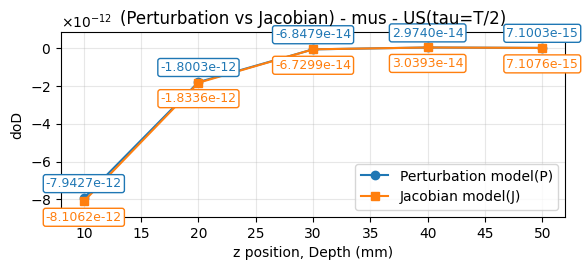

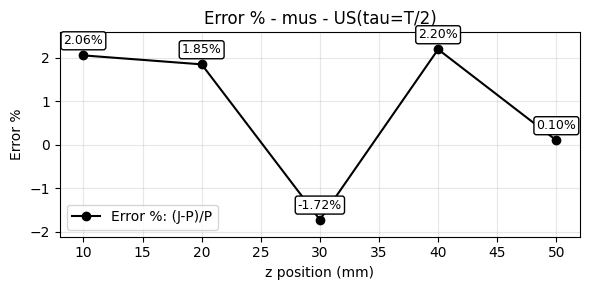

In [307]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Data
z_positions = []                   # creating an array that contains inclusion positions
for i in range(1, nPos+1):   
    z_positions.append(step * i)     
#print(z_positions)
x = z_positions
y_pert = doD_mus_pert[::-1]     # reversing to make it user friendly while displaying output(to display in ascending order of depth)
y_jac  = doD_mus_jacobian[::-1]
y_error = error_mus[::-1]    # reversing to make it user friendly while displaying output(to display in ascending order of depth)






# Comparison Plot
plt.figure(figsize=(6, 3))
line1, = plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model(P)')
line2, = plt.plot(x, y_jac,  marker='s', linewidth=1.5, label='Jacobian model(J)')
# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
# Zoom y-limits with padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Annotations: values at each point, colored by series and offset to avoid overlap
c1 = line1.get_color()
c2 = line2.get_color()
for xi, yi in zip(x, y_pert):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, 8), ha='center',
                color=c1, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c1, alpha=1))
for xi, yi in zip(x, y_jac):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, -14), ha='center',
                color=c2, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c2, alpha=1))
plt.xlabel('z position, Depth (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mus - US(tau=T/2)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()






# Error Plot
plt.figure(figsize=(6, 3))
line_err, = plt.plot(x, y_error, marker='o', linewidth=1.5, color='black', label='Error %: (J-P)/P')
# Zoom in around the min/max range with 10% padding
y_min = np.min(y_error)
y_max = np.max(y_error)
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Get the line color
c_err = line_err.get_color()
# Annotate each point
for xi, yi in zip(x, y_error):
    plt.annotate(f'{yi:.2f}%', (xi, yi),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 color=c_err, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c_err, alpha=1))
plt.xlabel('z position (mm)')
plt.ylabel('Error %')
plt.title('Error % - mus - US(tau=T/2)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

